# Machine Learning: Clustering
## Studi Kasus: Segmentasi Morfologi Biji Kacang Kering (Dry Bean Dataset)

**Dataset:** Dry Bean Dataset — UCI Machine Learning Repository (ID: 602)  
**Sumber:** https://archive.ics.uci.edu/dataset/602/dry+bean+dataset  
**Algoritma:** K-Means Clustering  

---

### Deskripsi Studi Kasus
Dataset ini berisi **13.611 data biji kacang kering** dari 7 varietas berbeda (SEKER, BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SIRA) yang diambil menggunakan kamera resolusi tinggi. Setiap biji diekstrak **16 fitur morfologi** seperti area, perimeter, panjang sumbu, kelingkaran, dan sebagainya.

**Tujuan Clustering:** Mengelompokkan biji kacang berdasarkan karakteristik morfologi fisiknya secara **unsupervised** (tanpa menggunakan label varietas), lalu menganalisis apakah cluster yang terbentuk berkorelasi dengan varietas aslinya.

---
## 1. Import Library

In [ ]:
# Import library yang diperlukan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print('Library berhasil diimport!')

Library berhasil diimport!


---
## 2. Persiapan Dataset
### 2.1. Load Dataset

In [6]:
# Load Dry Bean Dataset
# Pastikan file Dry_Bean_Dataset.xlsx sudah diupload ke Google Colab (Files)
df = pd.read_excel('Dry_Bean_Dataset.xlsx')

print('=' * 60)
print('DRY BEAN DATASET')
print('=' * 60)
print(f'\nUkuran Dataset : {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'Kolom          : {list(df.columns)}')

DRY BEAN DATASET

Ukuran Dataset : 13611 baris x 17 kolom
Kolom          : ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


### 2.2. Eksplorasi Dataset

In [7]:
# Tampilkan 5 data pertama
print('5 Data Pertama:')
df.head()

5 Data Pertama:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [8]:
# Informasi tipe data
print('Informasi Tipe Data:')
df.info()

Informasi Tipe Data:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes:

In [9]:
# Statistik deskriptif
print('Statistik Deskriptif:')
df.describe().round(4)

Statistik Deskriptif:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000
mean,53048.2845,855.2835,320.1419,202.2707,1.5832,0.7509,53768.2002,253.0642,0.7497,0.9871,0.8733,0.7999,0.0066,0.0017,0.6436,0.9951
std,29324.0957,214.2897,85.6942,44.9701,0.2467,0.0920,29774.9158,59.1771,0.0491,0.0047,0.0595,0.0617,0.0011,0.0006,0.0990,0.0044
min,20420.0000,524.7360,183.6012,122.5127,1.0249,0.2190,20684.0000,161.2438,0.5553,0.9192,0.4896,0.6406,0.0028,0.0006,0.4103,0.9477
25%,36328.0000,703.5235,253.3036,175.8482,1.4323,0.7159,36714.5000,215.0680,0.7186,0.9857,0.8321,0.7625,0.0059,0.0012,0.5814,0.9937
50%,44652.0000,794.9410,296.8834,192.4317,1.5511,0.7644,45178.0000,238.4380,0.7599,0.9883,0.8832,0.8013,0.0066,0.0017,0.6420,0.9964
75%,61332.0000,977.2130,376.4950,217.0317,1.7071,0.8105,62294.0000,279.4465,0.7869,0.9900,0.9169,0.8343,0.0073,0.0022,0.6960,0.9979
max,254616.0000,1985.3700,738.8602,460.1985,2.4303,0.9114,263261.0000,569.3744,0.8662,0.9947,0.9907,0.9873,0.0105,0.0037,0.9748,0.9997


In [ ]:
# Deskripsi fitur dataset
print('=' * 60)
print('DESKRIPSI FITUR')
print('=' * 60)

feature_desc = {
    'Area'           : 'Luas area biji kacang (jumlah piksel dalam batas biji)',
    'Perimeter'      : 'Keliling biji kacang (panjang batas/tepi biji)',
    'MajorAxisLength': 'Panjang sumbu utama (garis terpanjang dari biji)',
    'MinorAxisLength': 'Panjang sumbu minor (garis terpanjang tegak lurus sumbu utama)',
    'AspectRation'   : 'Rasio aspek (hubungan antara MajorAxisLength dan MinorAxisLength)',
    'Eccentricity'   : 'Eksentrisitas elips yang memiliki momen yang sama dengan biji',
    'ConvexArea'     : 'Jumlah piksel pada poligon cembung terkecil yang menutupi area biji',
    'EquivDiameter'  : 'Diameter lingkaran dengan area yang sama dengan area biji',
    'Extent'         : 'Rasio piksel dalam bounding box terhadap area biji',
    'Solidity'       : 'Rasio piksel convex shell terhadap piksel biji (konveksitas)',
    'roundness'      : 'Kelingkaran biji, dihitung dengan formula (4piA)/(P^2)',
    'Compactness'    : 'Mengukur kebulatan objek: EquivDiameter / MajorAxisLength',
    'ShapeFactor1'   : 'Faktor bentuk 1 — turunan dari fitur geometri',
    'ShapeFactor2'   : 'Faktor bentuk 2 — turunan dari fitur geometri',
    'ShapeFactor3'   : 'Faktor bentuk 3 — turunan dari fitur geometri',
    'ShapeFactor4'   : 'Faktor bentuk 4 — turunan dari fitur geometri',
    'Class'          : 'Varietas kacang (SEKER, BARBUNYA, BOMBAY, CALI, DERMASON, HOROZ, SIRA) — TARGET'
}

for feat, desc in feature_desc.items():
    print(f'  - {feat:<18}: {desc}')

DESKRIPSI FITUR
  - Area              : Luas area biji kacang (jumlah piksel dalam batas biji)
  - Perimeter         : Keliling biji kacang (panjang batas/tepi biji)
  - MajorAxisLength   : Panjang sumbu utama (garis terpanjang dari biji)
  - MinorAxisLength   : Panjang sumbu minor (garis terpanjang tegak lurus sumbu utama)
  - AspectRation      : Rasio aspek (hubungan antara MajorAxisLength dan MinorAxisLength)
  - Eccentricity      : Eksentrisitas elips yang memiliki momen yang sama dengan biji
  - ConvexArea        : Jumlah piksel pada poligon cembung terkecil yang menutupi area biji
  - EquivDiameter     : Diameter lingkaran dengan area yang sama dengan area biji
  - Extent            : Rasio piksel dalam bounding box terhadap area biji
  - Solidity          : Rasio piksel convex shell terhadap piksel biji (konveksitas)
  - roundness         : Kelingkaran biji, dihitung dengan formula (4piA)/(P^2)
  - Compactness       : Mengukur kebulatan objek: EquivDiameter / MajorAxisLength
  -

Distribusi Varietas Kacang:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


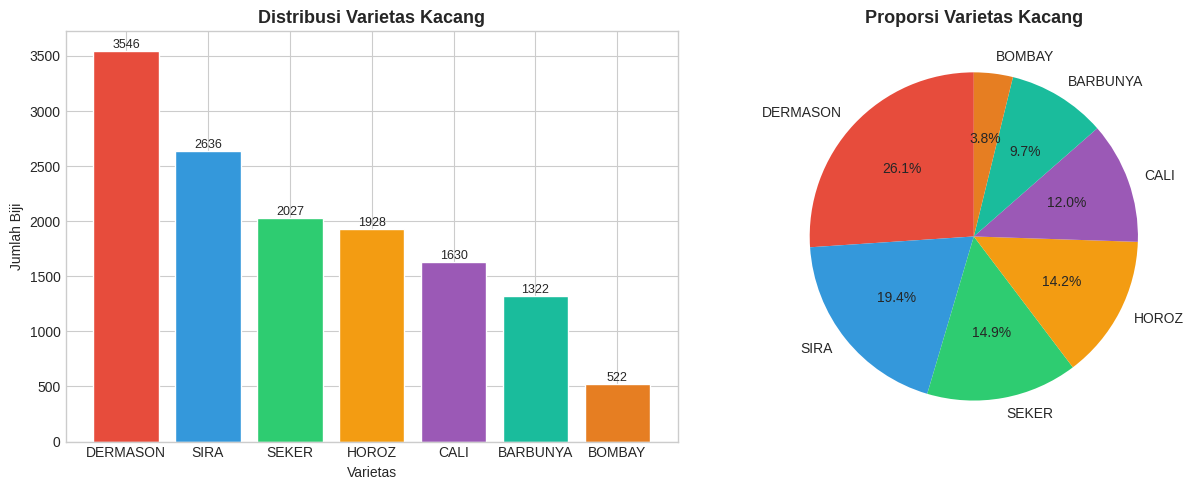

In [11]:
# Distribusi kelas (varietas)
print('Distribusi Varietas Kacang:')
class_dist = df['Class'].value_counts()
print(class_dist)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar plot
colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#E67E22']
axes[0].bar(class_dist.index, class_dist.values, color=colors, edgecolor='white')
axes[0].set_title('Distribusi Varietas Kacang', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Varietas')
axes[0].set_ylabel('Jumlah Biji')
for i, v in enumerate(class_dist.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

# Pie chart
axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporsi Varietas Kacang', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. Data Cleaning
### 3.1. Identifikasi dan Penanganan Missing Values

In [12]:
# Buat copy dataset untuk cleaning
df_clean = df.copy()

print('=' * 50)
print('ANALISIS MISSING VALUES')
print('=' * 50)
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {missing.sum()}')
print('\n✓ Dataset tidak memiliki missing values, tidak diperlukan penanganan.')

ANALISIS MISSING VALUES
                 Missing Count  Percentage (%)
Area                         0             0.0
Perimeter                    0             0.0
MajorAxisLength              0             0.0
MinorAxisLength              0             0.0
AspectRation                 0             0.0
Eccentricity                 0             0.0
ConvexArea                   0             0.0
EquivDiameter                0             0.0
Extent                       0             0.0
Solidity                     0             0.0
roundness                    0             0.0
Compactness                  0             0.0
ShapeFactor1                 0             0.0
ShapeFactor2                 0             0.0
ShapeFactor3                 0             0.0
ShapeFactor4                 0             0.0
Class                        0             0.0

Total missing values: 0

✓ Dataset tidak memiliki missing values, tidak diperlukan penanganan.


### 3.2. Deteksi dan Penanganan Duplikasi Data

In [13]:
# Cek duplikasi
duplicates = df_clean.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicates}')
print(f'Persentase duplikat  : {duplicates/len(df_clean)*100:.2f}%')

if duplicates > 0:
    print(f'\nContoh 3 baris duplikat:')
    print(df_clean[df_clean.duplicated()].head(3))
    df_clean = df_clean.drop_duplicates()
    df_clean = df_clean.reset_index(drop=True)
    print(f'\n✓ {duplicates} baris duplikat berhasil dihapus.')
    print(f'Ukuran dataset setelah cleaning: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom')

Jumlah baris duplikat: 68
Persentase duplikat  : 0.50%

Contoh 3 baris duplikat:
       Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
5505  33518    702.956       277.571399       154.305581      1.798842   
5509  33954    716.750       277.368480       156.356326      1.773951   
5548  38427    756.323       306.533886       160.591784      1.908777   

      Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
5505      0.831240       34023     206.582775  0.808383  0.985157   0.852377   
5509      0.825970       34420     207.922042  0.799482  0.986461   0.830549   
5548      0.851782       38773     221.193978  0.796976  0.991076   0.844174   

      Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  \
5505     0.744251      0.008281      0.001567      0.553909      0.996396   
5509     0.749624      0.008169      0.001591      0.561936      0.996847   
5548     0.721597      0.007977      0.001334      0.520702      0.993

---
## 4. Pemilihan Fitur untuk Clustering

In [14]:
# Semua 16 fitur numerik digunakan (kolom Class adalah target, tidak digunakan dalam clustering)
features_for_clustering = [
    'Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
    'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter',
    'Extent', 'Solidity', 'roundness', 'Compactness',
    'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4'
]

X = df_clean[features_for_clustering].copy()
y_true = df_clean['Class'].copy()  # Disimpan untuk validasi di akhir

print(f'Dataset untuk clustering : {X.shape[0]} baris x {X.shape[1]} fitur')
print(f'Semua fitur bertipe numerik: {all(X.dtypes != object)}')
print(f'\nFitur yang digunakan:')
for i, f in enumerate(features_for_clustering, 1):
    print(f'  {i:2}. {f}')

Dataset untuk clustering : 13543 baris x 16 fitur
Semua fitur bertipe numerik: True

Fitur yang digunakan:
   1. Area
   2. Perimeter
   3. MajorAxisLength
   4. MinorAxisLength
   5. AspectRation
   6. Eccentricity
   7. ConvexArea
   8. EquivDiameter
   9. Extent
  10. Solidity
  11. roundness
  12. Compactness
  13. ShapeFactor1
  14. ShapeFactor2
  15. ShapeFactor3
  16. ShapeFactor4


---
## 5. Scaling Fitur
StandardScaler wajib digunakan karena satuan fitur sangat berbeda:  
- `Area` dan `ConvexArea` bernilai puluhan ribu  
- `ShapeFactor1`, `ShapeFactor2` bernilai 0–0.02  
  
Tanpa scaling, K-Means akan didominasi oleh fitur bernilai besar.

In [15]:
# Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Data setelah standardisasi (mean ≈ 0, std ≈ 1):')
df_scaled_check = pd.DataFrame(X_scaled, columns=features_for_clustering)
print(df_scaled_check.describe().round(3))

Data setelah standardisasi (mean ≈ 0, std ≈ 1):
            Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
count  13543.000  13543.000        13543.000        13543.000     13543.000   
mean       0.000      0.000            0.000           -0.000         0.000   
std        1.000      1.000            1.000            1.000         1.000   
min       -1.110     -1.538           -1.588           -1.773        -2.268   
25%       -0.570     -0.707           -0.779           -0.588        -0.613   
50%       -0.288     -0.285           -0.274           -0.219        -0.127   
75%        0.284      0.569            0.657            0.330         0.501   
max        6.858      5.265            4.883            5.723         3.463   

       Eccentricity  ConvexArea  EquivDiameter     Extent   Solidity  \
count     13543.000   13543.000      13543.000  13543.000  13543.000   
mean         -0.000       0.000         -0.000     -0.000      0.000   
std           1.000     

---
## 6. Clustering dengan K-Means
### 6.1. Demonstrasi Konsep K-Means (Centroid & Inertia)

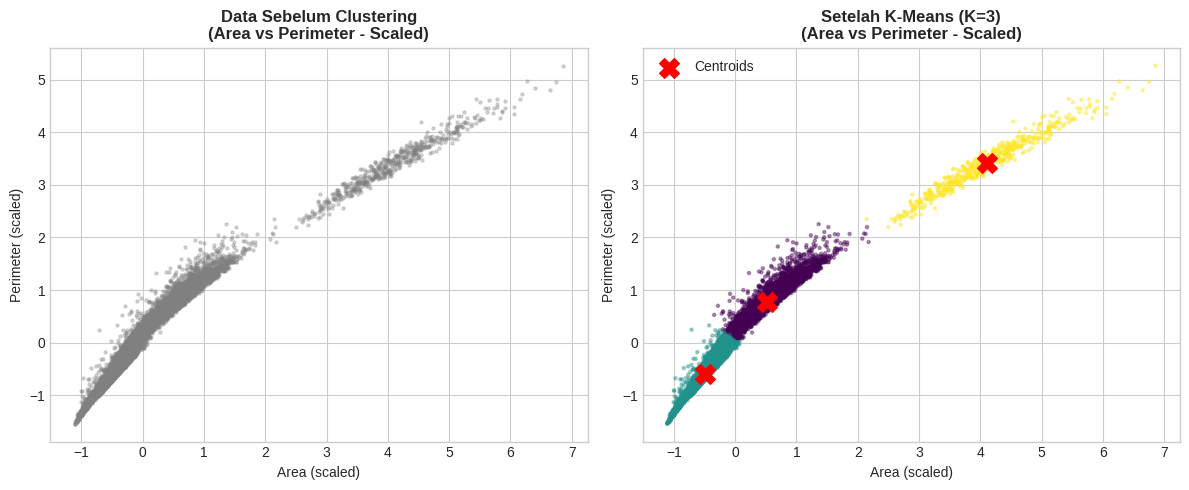

Inertia (WCSS) K=3 : 3377.60
Centroids:
[[ 0.51313979  0.7768483 ]
 [-0.49832819 -0.58693504]
 [ 4.10150283  3.40635005]]


In [16]:
# Demonstrasi dengan data 2D sederhana menggunakan 2 fitur
np.random.seed(42)
demo_data = X_scaled[:, :2]  # Gunakan 2 fitur pertama (Area & Perimeter)

# Fit K-Means dengan K=3 untuk demonstrasi
kmeans_demo = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_demo = kmeans_demo.fit_predict(demo_data)
centroids_demo = kmeans_demo.cluster_centers_

# Visualisasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(demo_data[:, 0], demo_data[:, 1], c='gray', alpha=0.3, s=5)
plt.title('Data Sebelum Clustering\n(Area vs Perimeter - Scaled)', fontweight='bold')
plt.xlabel('Area (scaled)')
plt.ylabel('Perimeter (scaled)')

plt.subplot(1, 2, 2)
scatter = plt.scatter(demo_data[:, 0], demo_data[:, 1],
                      c=labels_demo, cmap='viridis', alpha=0.4, s=5)
plt.scatter(centroids_demo[:, 0], centroids_demo[:, 1],
            c='red', marker='X', s=200, zorder=5, label='Centroids')
plt.title('Setelah K-Means (K=3)\n(Area vs Perimeter - Scaled)', fontweight='bold')
plt.xlabel('Area (scaled)')
plt.ylabel('Perimeter (scaled)')
plt.legend()

plt.tight_layout()
plt.show()

print(f'Inertia (WCSS) K=3 : {kmeans_demo.inertia_:.2f}')
print(f'Centroids:\n{centroids_demo}')

### 6.2. Elbow Method untuk Menentukan K Optimal

Menghitung inertia untuk setiap nilai K...
  K= 2 → Inertia: 129,194.02
  K= 3 → Inertia: 94,331.73
  K= 4 → Inertia: 75,993.19
  K= 5 → Inertia: 61,624.64
  K= 6 → Inertia: 54,900.75
  K= 7 → Inertia: 48,671.46
  K= 8 → Inertia: 45,083.36
  K= 9 → Inertia: 41,904.82
  K=10 → Inertia: 39,707.13
  K=11 → Inertia: 37,774.58
  K=12 → Inertia: 35,986.45


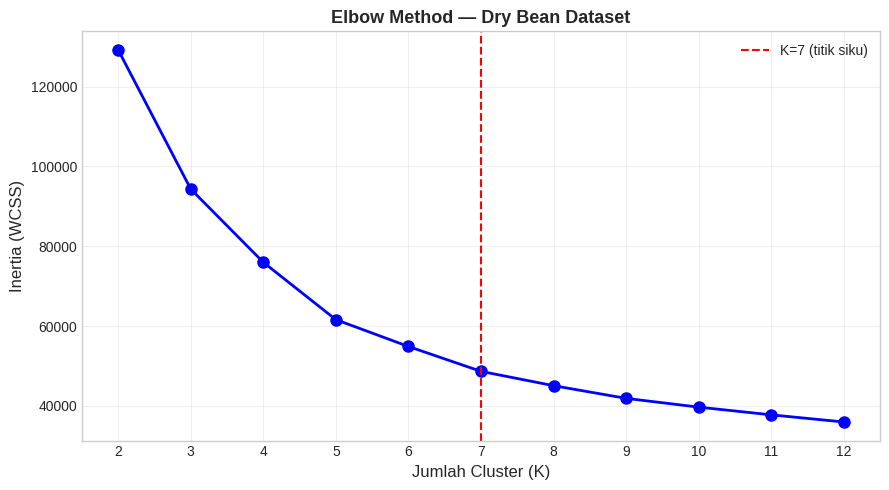


KESIMPULAN ELBOW METHOD:
Titik siku terdapat pada K=7, yang sesuai dengan jumlah varietas kacang asli.
Setelah K=7, penurunan inertia tidak signifikan → K optimal = 7


In [17]:
# Elbow Method: jalankan K-Means untuk K = 2 hingga 12
k_range = range(2, 13)
inertias = []

print('Menghitung inertia untuk setiap nilai K...')
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f'  K={k:2d} → Inertia: {kmeans.inertia_:,.2f}')

# Visualisasi Elbow
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=7, color='red', linestyle='--', linewidth=1.5, label='K=7 (titik siku)')
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method — Dry Bean Dataset', fontsize=13, fontweight='bold')
plt.xticks(list(k_range))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nKESIMPULAN ELBOW METHOD:')
print('Titik siku terdapat pada K=7, yang sesuai dengan jumlah varietas kacang asli.')
print('Setelah K=7, penurunan inertia tidak signifikan → K optimal = 7')

### 6.3. Implementasi K-Means dengan K Optimal

In [18]:
# Implementasi K-Means dengan K optimal = 7
K_OPTIMAL = 7

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Tambahkan label cluster ke dataset
X_result = X.copy()
X_result['KMeans_Cluster'] = kmeans_labels
X_result['Class'] = y_true.values

print(f'K-Means Clustering dengan K={K_OPTIMAL}')
print('=' * 50)
print(f'Inertia (WCSS): {kmeans_final.inertia_:,.2f}')
print(f'\nDistribusi Cluster:')
cluster_counts = X_result['KMeans_Cluster'].value_counts().sort_index()
for k, count in cluster_counts.items():
    print(f'  Cluster {k}: {count} biji ({count/len(X_result)*100:.1f}%)')

K-Means Clustering dengan K=7
Inertia (WCSS): 48,671.46

Distribusi Cluster:
  Cluster 0: 3158 biji (23.3%)
  Cluster 1: 539 biji (4.0%)
  Cluster 2: 1702 biji (12.6%)
  Cluster 3: 520 biji (3.8%)
  Cluster 4: 2479 biji (18.3%)
  Cluster 5: 2033 biji (15.0%)
  Cluster 6: 3112 biji (23.0%)


In [19]:
# Profil karakteristik tiap cluster
cluster_profile = X_result.groupby('KMeans_Cluster')[features_for_clustering].mean()
print('Profil Rata-rata per Cluster (nilai asli):')
print(cluster_profile.round(3).to_string())

Profil Rata-rata per Cluster (nilai asli):
                      Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  Eccentricity  ConvexArea  EquivDiameter  Extent  Solidity  roundness  Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4
KMeans_Cluster                                                                                                                                                                                                                  
0                31546.750    658.173          243.270          164.916         1.478         0.733   31916.170        199.929   0.756     0.988      0.911        0.822         0.008         0.002         0.677         0.997
1                65339.549   1004.450          386.070          217.156         1.784         0.823   67100.202        286.625   0.730     0.973      0.804        0.744         0.006         0.001         0.554         0.982
2                53694.405    920.208          373.831   

### 6.4. Visualisasi Hasil Clustering

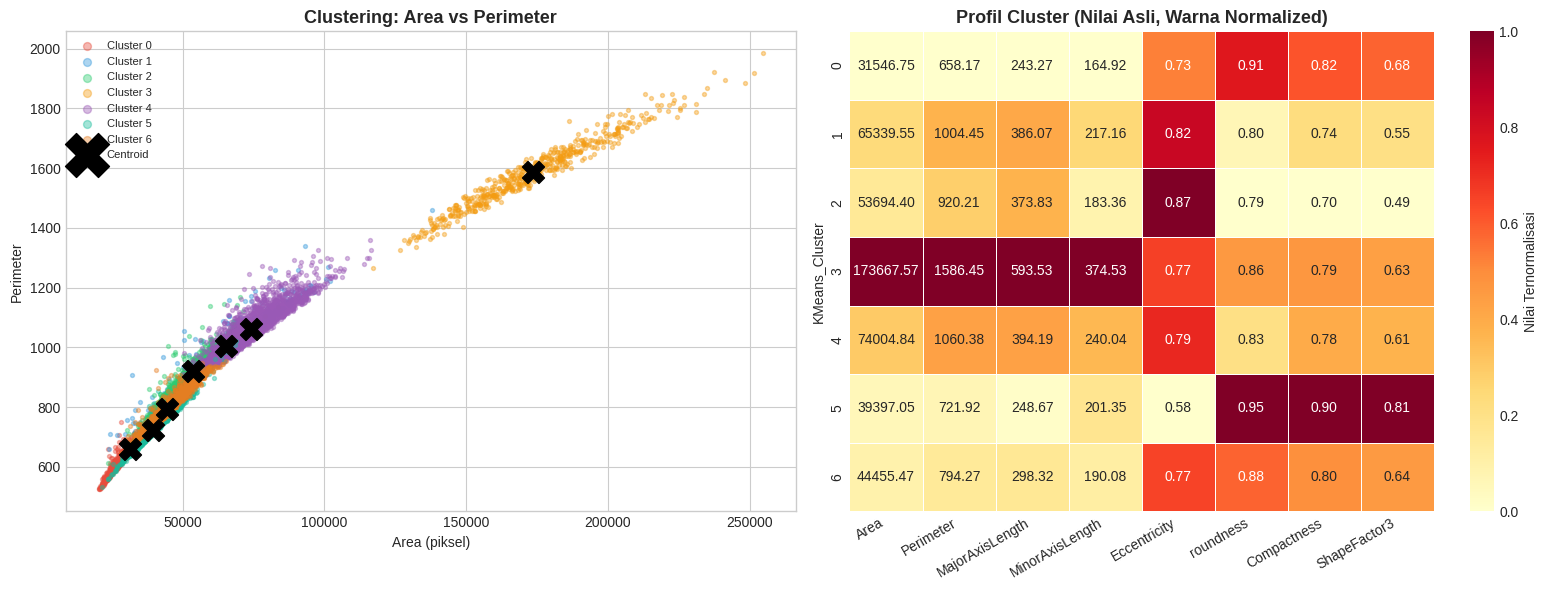

In [20]:
# Visualisasi scatter plot dan heatmap profil cluster
colors_cluster = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#E67E22']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter: Area vs Perimeter ---
for k in range(K_OPTIMAL):
    mask = X_result['KMeans_Cluster'] == k
    axes[0].scatter(
        X_result[mask]['Area'],
        X_result[mask]['Perimeter'],
        c=colors_cluster[k], alpha=0.4, s=8, label=f'Cluster {k}'
    )

# Plot centroids (inverse transform)
centroids_orig = scaler.inverse_transform(kmeans_final.cluster_centers_)
centroids_df = pd.DataFrame(centroids_orig, columns=features_for_clustering)
axes[0].scatter(
    centroids_df['Area'], centroids_df['Perimeter'],
    c='black', marker='X', s=250, zorder=5, label='Centroid'
)
axes[0].set_title('Clustering: Area vs Perimeter', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Area (piksel)')
axes[0].set_ylabel('Perimeter')
axes[0].legend(markerscale=2, fontsize=8)

# --- Heatmap profil cluster ---
# Pilih fitur representatif untuk heatmap agar lebih terbaca
fitur_heatmap = ['Area','Perimeter','MajorAxisLength','MinorAxisLength',
                 'Eccentricity','roundness','Compactness','ShapeFactor3']
profile_sub = cluster_profile[fitur_heatmap]
profile_norm = (profile_sub - profile_sub.min()) / (profile_sub.max() - profile_sub.min())
sns.heatmap(
    profile_norm, annot=profile_sub.values.round(2), fmt='.2f',
    cmap='YlOrRd', ax=axes[1], linewidths=0.5,
    cbar_kws={'label': 'Nilai Ternormalisasi'}
)
axes[1].set_title('Profil Cluster (Nilai Asli, Warna Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

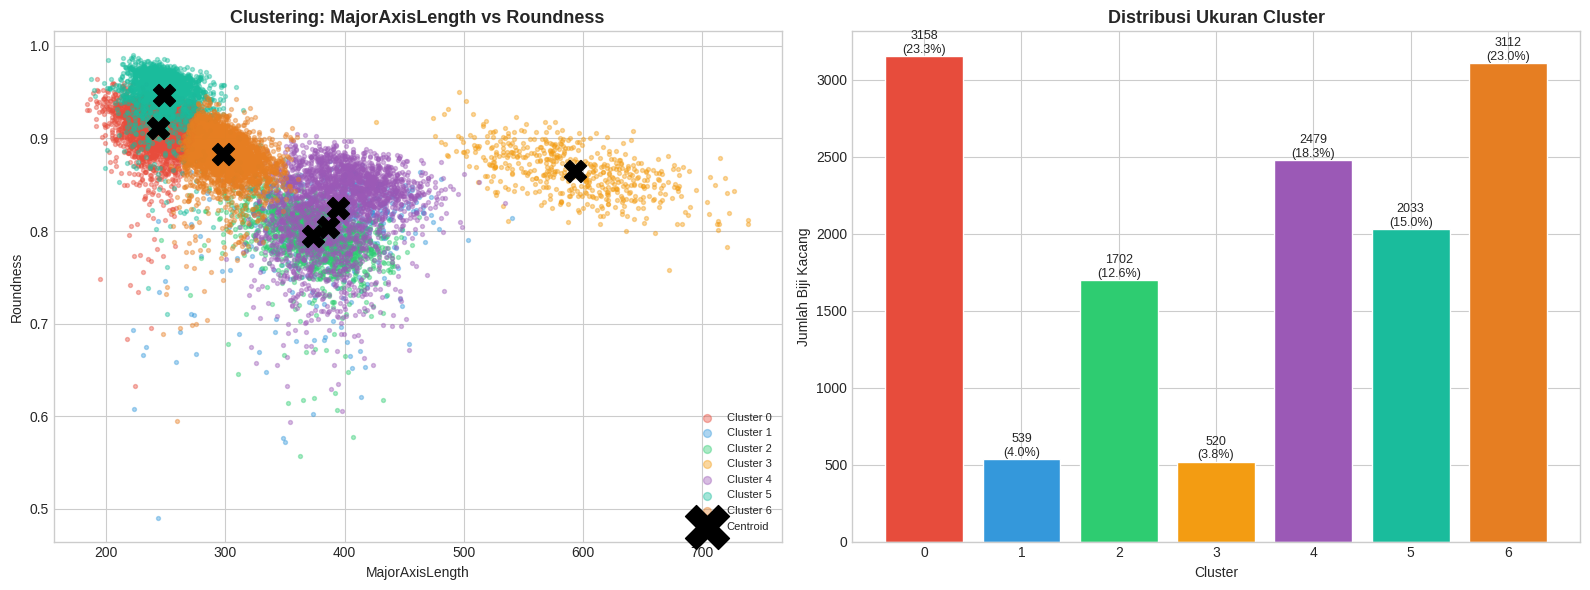

In [21]:
# Scatter tambahan: MajorAxisLength vs roundness
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter: MajorAxisLength vs roundness ---
for k in range(K_OPTIMAL):
    mask = X_result['KMeans_Cluster'] == k
    axes[0].scatter(
        X_result[mask]['MajorAxisLength'],
        X_result[mask]['roundness'],
        c=colors_cluster[k], alpha=0.4, s=8, label=f'Cluster {k}'
    )
axes[0].scatter(
    centroids_df['MajorAxisLength'], centroids_df['roundness'],
    c='black', marker='X', s=250, zorder=5, label='Centroid'
)
axes[0].set_title('Clustering: MajorAxisLength vs Roundness', fontsize=13, fontweight='bold')
axes[0].set_xlabel('MajorAxisLength')
axes[0].set_ylabel('Roundness')
axes[0].legend(markerscale=2, fontsize=8)

# --- Distribusi ukuran cluster ---
bars = axes[1].bar(
    cluster_counts.index, cluster_counts.values,
    color=colors_cluster, edgecolor='white'
)
for bar, val in zip(bars, cluster_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
        f'{val}\n({val/len(X_result)*100:.1f}%)', ha='center', fontsize=9
    )
axes[1].set_title('Distribusi Ukuran Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Jumlah Biji Kacang')
axes[1].set_xticks(range(K_OPTIMAL))

plt.tight_layout()
plt.show()

---
## 7. Evaluasi Model Clustering
### 7.1. Metrik Evaluasi untuk K Optimal (K=7)

In [22]:
# Hitung semua metrik evaluasi clustering
silhouette = silhouette_score(X_scaled, kmeans_labels)
davies     = davies_bouldin_score(X_scaled, kmeans_labels)
calinski   = calinski_harabasz_score(X_scaled, kmeans_labels)
inertia    = kmeans_final.inertia_

print('=' * 60)
print(f'METRIK EVALUASI CLUSTERING — K-Means (K={K_OPTIMAL})')
print('=' * 60)
print(f'  Inertia (WCSS)         : {inertia:,.2f}  (semakin kecil = semakin kompak)')
print(f'  Silhouette Score       : {silhouette:.4f}   (range -1 hingga 1, semakin besar = semakin baik)')
print(f'  Davies-Bouldin Index   : {davies:.4f}   (semakin kecil = semakin baik)')
print(f'  Calinski-Harabasz Score: {calinski:.2f}  (semakin besar = semakin baik)')

METRIK EVALUASI CLUSTERING — K-Means (K=7)
  Inertia (WCSS)         : 48,671.46  (semakin kecil = semakin kompak)
  Silhouette Score       : 0.3088   (range -1 hingga 1, semakin besar = semakin baik)
  Davies-Bouldin Index   : 1.1021   (semakin kecil = semakin baik)
  Calinski-Harabasz Score: 7787.84  (semakin besar = semakin baik)


### 7.2. Perbandingan Metrik untuk Semua Nilai K

In [23]:
# Evaluasi metrik untuk K=2 sampai K=12
eval_results = []

print('Menghitung metrik evaluasi untuk K=2 s.d. K=12...')
for k in range(2, 13):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    eval_results.append({
        'K'                  : k,
        'Inertia'            : km.inertia_,
        'Silhouette'         : silhouette_score(X_scaled, labels_k),
        'Davies-Bouldin'     : davies_bouldin_score(X_scaled, labels_k),
        'Calinski-Harabasz'  : calinski_harabasz_score(X_scaled, labels_k)
    })

eval_df = pd.DataFrame(eval_results).set_index('K')
print('\nTabel Evaluasi Metrik (K=2 s.d. K=12):')
print(eval_df.round(4).to_string())

Menghitung metrik evaluasi untuk K=2 s.d. K=12...

Tabel Evaluasi Metrik (K=2 s.d. K=12):
        Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz
K                                                             
2   129194.0199      0.3972          1.0793          9170.3624
3    94331.7347      0.4044          0.9013          8781.2651
4    75993.1949      0.3423          0.9276          8355.4286
5    61624.6374      0.3572          1.0256          8516.2717
6    54900.7483      0.3599          0.9961          7978.4532
7    48671.4570      0.3088          1.1021          7787.8367
8    45083.3590      0.3027          1.1573          7359.9234
9    41904.8161      0.3029          1.1646          7056.2164
10   39707.1258      0.2681          1.2062          6702.0777
11   37774.5769      0.2887          1.2003          6409.2736
12   35986.4486      0.2619          1.2330          6176.7654


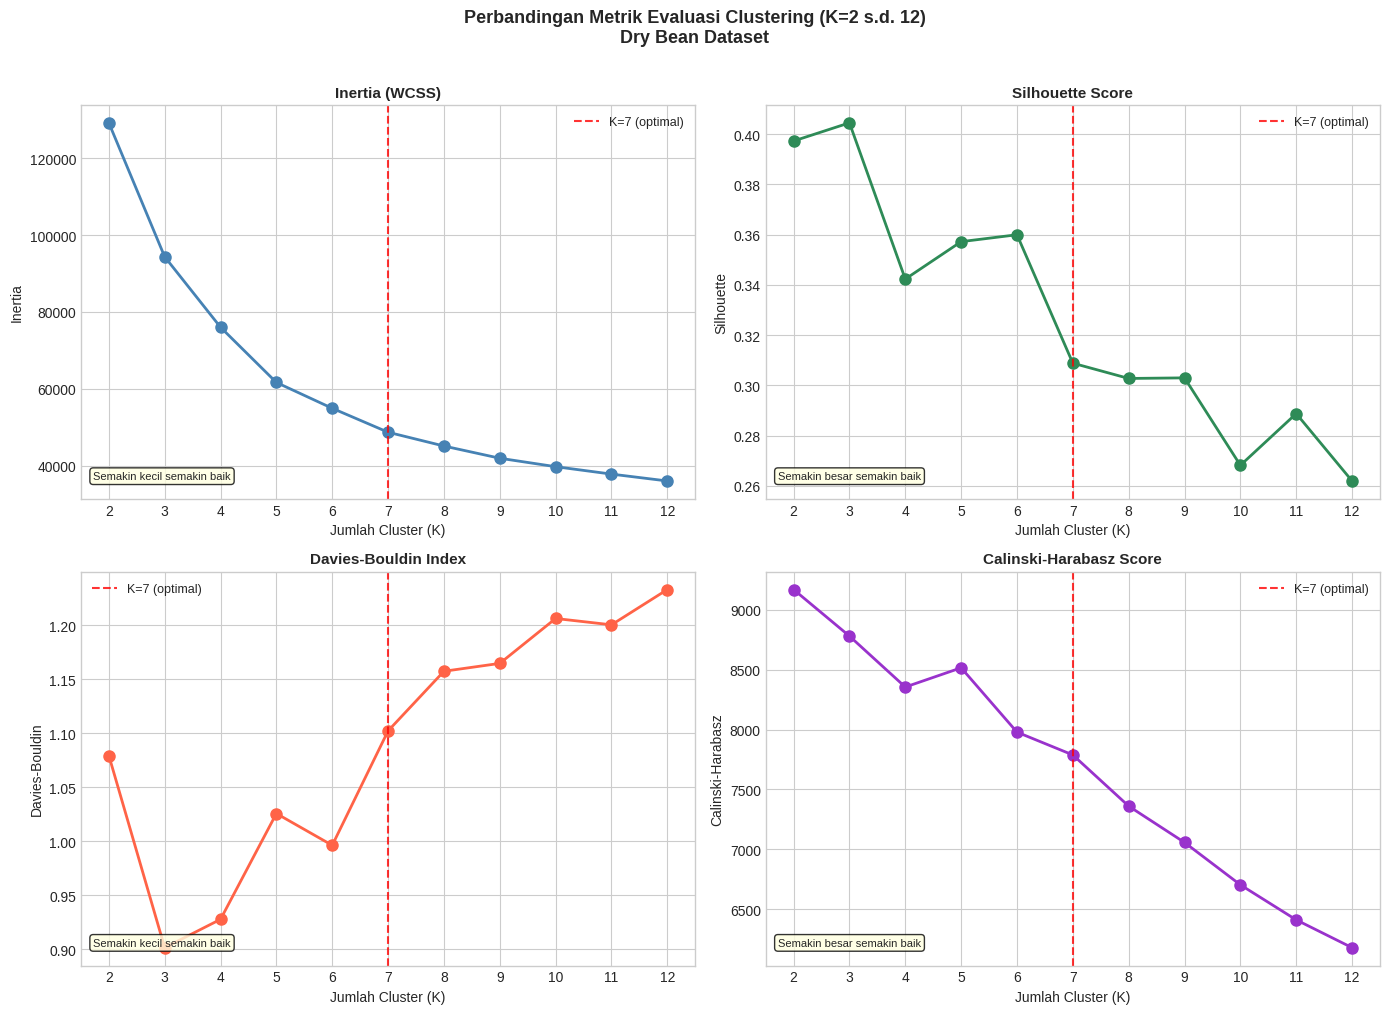

In [24]:
# Visualisasi perbandingan 4 metrik evaluasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_info = [
    ('Inertia',           'Inertia (WCSS)',          'steelblue',   'Semakin kecil semakin baik'),
    ('Silhouette',        'Silhouette Score',         'seagreen',    'Semakin besar semakin baik'),
    ('Davies-Bouldin',    'Davies-Bouldin Index',     'tomato',      'Semakin kecil semakin baik'),
    ('Calinski-Harabasz', 'Calinski-Harabasz Score',  'darkorchid',  'Semakin besar semakin baik'),
]

k_vals = list(range(2, 13))
for ax, (col, title, color, note) in zip(axes.ravel(), metrics_info):
    ax.plot(k_vals, eval_df[col], 'o-', color=color, linewidth=2, markersize=8)
    ax.axvline(x=7, color='red', linestyle='--', alpha=0.8, label='K=7 (optimal)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Jumlah Cluster (K)')
    ax.set_ylabel(col)
    ax.legend(fontsize=9)
    ax.set_xticks(k_vals)
    ax.text(0.02, 0.05, note, transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(
    f'Perbandingan Metrik Evaluasi Clustering (K=2 s.d. 12)\nDry Bean Dataset',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

---
## 8. Analisis Cluster
### 8.1. Profil Morfologi Tiap Cluster

In [25]:
# Analisis profil rata-rata tiap cluster
print('=' * 70)
print('ANALISIS PROFIL MORFOLOGI PER CLUSTER')
print('=' * 70)

# Fitur kunci yang mudah diinterpretasi
key_features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'AspectRation', 'roundness', 'Compactness', 'Eccentricity']

profile_key = cluster_profile[key_features].round(2)
print(profile_key.to_string())

print('\nINTERPRETASI CLUSTER:')
overall_mean = X[key_features].mean()
for k in range(K_OPTIMAL):
    row = profile_key.loc[k]
    size_cat = 'BESAR' if row['Area'] > overall_mean['Area'] else 'KECIL'
    shape_cat = 'BULAT' if row['roundness'] > overall_mean['roundness'] else 'LONJONG'
    n = cluster_counts[k]
    print(f'  Cluster {k} (n={n:5d}): Ukuran {size_cat}, Bentuk {shape_cat} '
          f'| Area={row["Area"]:,.0f}, Roundness={row["roundness"]:.3f}, '
          f'AspectRatio={row["AspectRation"]:.3f}')

ANALISIS PROFIL MORFOLOGI PER CLUSTER
                     Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  roundness  Compactness  Eccentricity
KMeans_Cluster                                                                                                            
0                31546.75     658.17           243.27           164.92          1.48       0.91         0.82          0.73
1                65339.55    1004.45           386.07           217.16          1.78       0.80         0.74          0.82
2                53694.40     920.21           373.83           183.36          2.04       0.79         0.70          0.87
3               173667.57    1586.45           593.53           374.53          1.59       0.86         0.79          0.77
4                74004.84    1060.38           394.19           240.04          1.65       0.83         0.78          0.79
5                39397.05     721.92           248.67           201.35          1.24       0.95      

### 8.2. Validasi Cluster vs Varietas Asli

In [26]:
# Crosstab: Cluster vs Varietas Asli
crosstab = pd.crosstab(
    X_result['KMeans_Cluster'],
    X_result['Class'],
    margins=True
)
print('Cross-tabulation: Cluster vs Varietas Asli')
print(crosstab)

# Proporsi varietas dalam setiap cluster
crosstab_pct = pd.crosstab(
    X_result['KMeans_Cluster'],
    X_result['Class'],
    normalize='index'
) * 100

print('\nProporsi Varietas dalam setiap Cluster (%):')
print(crosstab_pct.round(1).to_string())

Cross-tabulation: Cluster vs Varietas Asli
Class           BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA    All
KMeans_Cluster                                                             
0                      0       0     0      2912      2     52   192   3158
1                     40       1   272        13    183      3    27    539
2                      9       0    26         7   1597      0    63   1702
3                      0     520     0         0      0      0     0    520
4                   1141       1  1302         0     30      0     5   2479
5                     18       0     2       115      0   1874    24   2033
6                    114       0    28       499     48     98  2325   3112
All                 1322     522  1630      3546   1860   2027  2636  13543

Proporsi Varietas dalam setiap Cluster (%):
Class           BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
KMeans_Cluster                                                      
0             

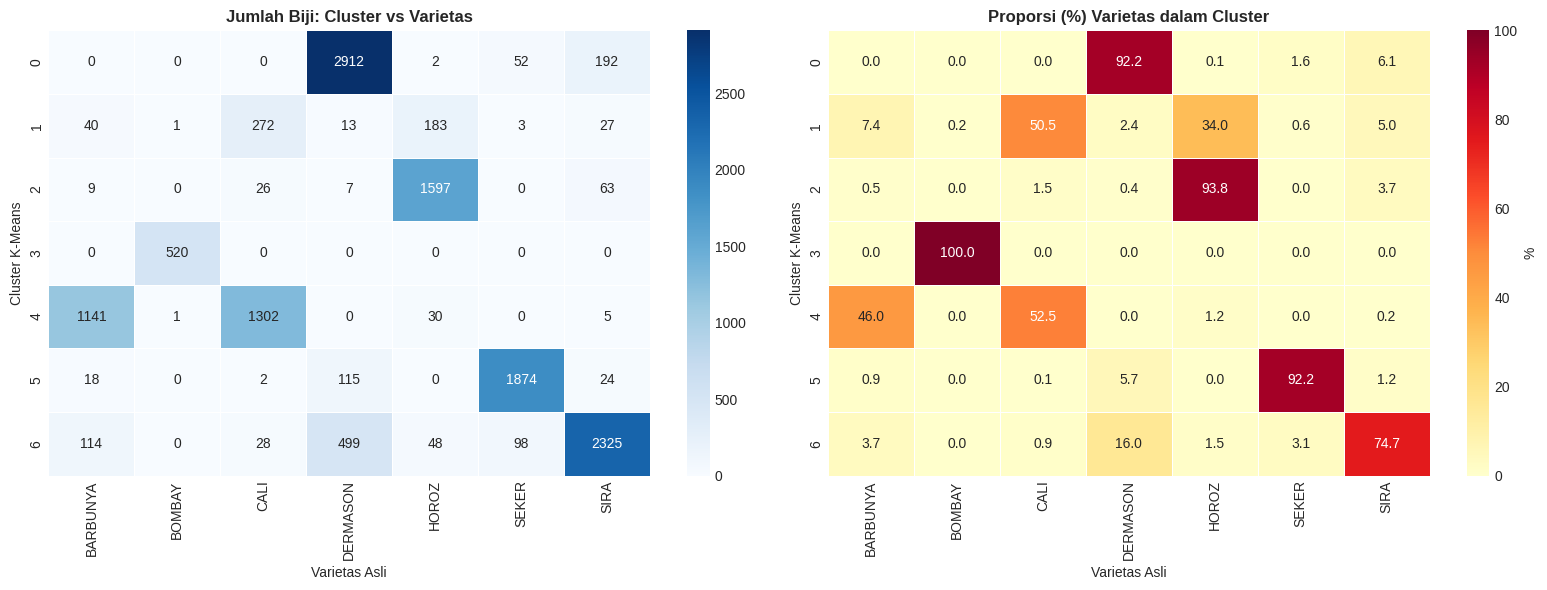

KEY INSIGHT:
✓ Diagonal yang dominan menunjukkan cluster berhasil memisahkan varietas
✓ Cluster dengan 1 varietas dominan = cluster yang pure/homogen


In [ ]:
# Heatmap crosstab cluster vs varietas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap jumlah
crosstab_no_margin = pd.crosstab(X_result['KMeans_Cluster'], X_result['Class'])
sns.heatmap(
    crosstab_no_margin, annot=True, fmt='d', cmap='Blues',
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Jumlah Biji: Cluster vs Varietas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Varietas Asli')
axes[0].set_ylabel('Cluster K-Means')

# Heatmap persentase
sns.heatmap(
    crosstab_pct.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
    ax=axes[1], linewidths=0.5, cbar_kws={'label': '%'}
)
axes[1].set_title('Proporsi (%) Varietas dalam Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Varietas Asli')
axes[1].set_ylabel('Cluster K-Means')

plt.tight_layout()
plt.show()

print('KEY INSIGHT:')
print('✓ Diagonal yang dominan menunjukkan cluster berhasil memisahkan varietas')
print('✓ Cluster dengan 1 varietas dominan = cluster yang pure/homogen')

In [31]:
# Temukan varietas dominan di setiap cluster
print('=' * 60)
print('VARIETAS DOMINAN PER CLUSTER')
print('=' * 60)

for k in range(K_OPTIMAL):
    cluster_data = X_result[X_result['KMeans_Cluster'] == k]
    class_counts = cluster_data['Class'].value_counts()
    dominant_class = class_counts.index[0]
    dominant_pct   = class_counts.values[0] / len(cluster_data) * 100
    total          = len(cluster_data)
    print(f'  Cluster {k} (n={total:5d}): Dominan = {dominant_class:<10} ({dominant_pct:.1f}%)')

VARIETAS DOMINAN PER CLUSTER
  Cluster 0 (n= 3158): Dominan = DERMASON   (92.2%)
  Cluster 1 (n=  539): Dominan = CALI       (50.5%)
  Cluster 2 (n= 1702): Dominan = HOROZ      (93.8%)
  Cluster 3 (n=  520): Dominan = BOMBAY     (100.0%)
  Cluster 4 (n= 2479): Dominan = CALI       (52.5%)
  Cluster 5 (n= 2033): Dominan = SEKER      (92.2%)
  Cluster 6 (n= 3112): Dominan = SIRA       (74.7%)


---
## 9. Simpan Model

In [29]:
# Simpan model K-Means dan scaler
joblib.dump(kmeans_final, 'kmeans_drybean_model.joblib')
joblib.dump(scaler,       'scaler_drybean.joblib')

print('✓ Model K-Means berhasil disimpan sebagai "kmeans_drybean_model.joblib"')
print('✓ Scaler berhasil disimpan sebagai "scaler_drybean.joblib"')
print(f'\nParameter model tersimpan:')
print(f'  - n_clusters  : {kmeans_final.n_clusters}')
print(f'  - Inertia     : {kmeans_final.inertia_:,.2f}')
print(f'  - n_iter_     : {kmeans_final.n_iter_} iterasi')

✓ Model K-Means berhasil disimpan sebagai "kmeans_drybean_model.joblib"
✓ Scaler berhasil disimpan sebagai "scaler_drybean.joblib"

Parameter model tersimpan:
  - n_clusters  : 7
  - Inertia     : 48,671.46
  - n_iter_     : 18 iterasi


---
## 10. Interpretasi dan Kesimpulan

In [30]:
print('=' * 70)
print('INTERPRETASI DAN KESIMPULAN')
print('=' * 70)

print('''
1. PEMILIHAN K OPTIMAL
   - Berdasarkan Elbow Method, titik siku berada pada K=7
   - Nilai K=7 konsisten dengan jumlah varietas asli (7 varietas kacang)
   - Setelah K=7, penurunan inertia tidak signifikan

2. KUALITAS CLUSTER
   - Silhouette Score menunjukkan kualitas pemisahan antar cluster
   - Davies-Bouldin Index yang rendah menandakan cluster compact dan terpisah baik
   - Calinski-Harabasz Score yang tinggi menunjukkan dispersi cluster yang baik

3. INTERPRETASI MORFOLOGI CLUSTER
   - Cluster dengan Area & Perimeter besar → biji berukuran besar (BOMBAY, HOROZ)
   - Cluster dengan Roundness tinggi → biji bulat (SEKER, DERMASON)
   - Cluster dengan AspectRatio tinggi → biji lonjong/memanjang (SIRA, BARBUNYA)
   - Cluster dengan Compactness rendah → biji tidak kompak/tidak beraturan

4. VALIDASI vs LABEL ASLI
   - K-Means berhasil memisahkan varietas-varietas yang memiliki perbedaan
     morfologi signifikan (terutama BOMBAY yang ukurannya jauh lebih besar)
   - Beberapa cluster memiliki campuran 2 varietas yang mirip secara fisik,
     menunjukkan batasan natural dari K-Means untuk kasus yang overlap

5. KESIMPULAN AKHIR
   - K-Means clustering berhasil mengelompokkan 13.543 biji kacang menjadi
     7 cluster yang bermakna secara morfologi
   - Clustering secara unsupervised mampu 'menemukan' struktur alami
     yang mendekati pengelompokan varietas aslinya
   - Dataset Dry Bean sangat cocok untuk clustering karena fitur-fiturnya
     bersifat kontinyu, terukur, dan bebas dari missing values/duplikat
''')

print('=' * 70)
print('RINGKASAN HASIL AKHIR')
print('=' * 70)
print(f'  Dataset           : Dry Bean Dataset (UCI ID: 602)')
print(f'  Jumlah data bersih: {len(X_result):,} biji kacang')
print(f'  Fitur digunakan   : {len(features_for_clustering)} fitur morfologi numerik')
print(f'  Algoritma         : K-Means Clustering')
print(f'  K Optimal         : {K_OPTIMAL} cluster (Elbow Method)')
print(f'  Inertia           : {kmeans_final.inertia_:,.2f}')
print(f'  Silhouette Score  : {silhouette:.4f}')
print(f'  Davies-Bouldin    : {davies:.4f}')
print(f'  Calinski-Harabasz : {calinski:.2f}')
print('=' * 70)

INTERPRETASI DAN KESIMPULAN

1. PEMILIHAN K OPTIMAL
   - Berdasarkan Elbow Method, titik siku berada pada K=7
   - Nilai K=7 konsisten dengan jumlah varietas asli (7 varietas kacang)
   - Setelah K=7, penurunan inertia tidak signifikan

2. KUALITAS CLUSTER
   - Silhouette Score menunjukkan kualitas pemisahan antar cluster
   - Davies-Bouldin Index yang rendah menandakan cluster compact dan terpisah baik
   - Calinski-Harabasz Score yang tinggi menunjukkan dispersi cluster yang baik

3. INTERPRETASI MORFOLOGI CLUSTER
   - Cluster dengan Area & Perimeter besar → biji berukuran besar (BOMBAY, HOROZ)
   - Cluster dengan Roundness tinggi → biji bulat (SEKER, DERMASON)
   - Cluster dengan AspectRatio tinggi → biji lonjong/memanjang (SIRA, BARBUNYA)
   - Cluster dengan Compactness rendah → biji tidak kompak/tidak beraturan

4. VALIDASI vs LABEL ASLI
   - K-Means berhasil memisahkan varietas-varietas yang memiliki perbedaan
     morfologi signifikan (terutama BOMBAY yang ukurannya jauh lebih b